# Notebook 07 — Error Analysis

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

## 1. Notebook Goal

Notebook 06 established the final, unbiased test performance of the selected Fine-Tuned
MobileNetV2: **99.00% accuracy**, 25 misclassified images out of 2,497. That single number
doesn't tell us *what kinds* of images the model gets wrong -- two models with identical accuracy
could be failing on completely different, informative patterns.

This notebook investigates those 25 errors. It:

1. Identifies the misclassified test images.
2. Examines their predicted probabilities.
3. Distinguishes false Dogs (Cat predicted as Dog) from false Cats (Dog predicted as Cat).
4. Visualizes representative errors.
5. Investigates whether difficult visual patterns are present.
6. Examines the most confident mistakes.
7. Summarizes the findings -- without changing the model.

**This is an analysis notebook, not another training notebook.** The 99.00% test accuracy from
Notebook 06 is the final, authoritative quantitative result and is not recalculated or changed
here. Nothing in this notebook feeds back into the model, the threshold, or model selection.


## 2. Imports and Configuration

**What are we doing?** Reusing the exact same setup as every previous notebook.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MANIFEST_PATH = Path("clean_manifest.csv")
MODEL_PATH = Path("finetuned_mobilenetv2.keras")

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

CLASS_NAMES = {0: "Cat", 1: "Dog"}

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 3. Recreate the Official Split

**What are we doing?** Recreating the exact same split used in Notebooks 02, 05, and 06 -- same
seed, same logic. We do not create a new split or sample a different test set.


In [2]:
manifest_df = pd.read_csv(MANIFEST_PATH)

assert len(manifest_df) == 24_966, f"Expected 24,966 manifest rows, got {len(manifest_df)}"
assert (manifest_df["class_name"] == "Cat").sum() == 12_480, "Cat count does not match the official audit"
assert (manifest_df["class_name"] == "Dog").sum() == 12_486, "Dog count does not match the official audit"

train_df, temp_df = train_test_split(
    manifest_df, test_size=0.2, stratify=manifest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

assert len(train_df) == 19_972, f"Expected 19,972 training rows, got {len(train_df)}"
assert len(val_df) == 2_497, f"Expected 2,497 validation rows, got {len(val_df)}"
assert len(test_df) == 2_497, f"Expected 2,497 test rows, got {len(test_df)}"

train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])
assert train_paths.isdisjoint(val_paths), "Train/validation overlap found"
assert train_paths.isdisjoint(test_paths), "Train/test overlap found"
assert val_paths.isdisjoint(test_paths), "Validation/test overlap found"

print("Split verified. Test set:", len(test_df), "images -- identical to Notebook 06.")


Split verified. Test set: 2497 images -- identical to Notebook 06.


## 4. Load the Selected Model

**What are we doing?** Loading the exact saved Fine-Tuned MobileNetV2 from Notebook 05 -- no
retraining, no rebuilding. If this fails, we stop rather than silently creating a replacement.


In [3]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Could not find '{MODEL_PATH}'. Notebook 07 requires the trained Fine-Tuned MobileNetV2 "
        "saved by Notebook 05 -- it does not train or rebuild a model."
    )

try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    raise RuntimeError(f"Found '{MODEL_PATH}' but failed to load it. Original error: {e}")

assert model.input_shape == (None, 180, 180, 3), f"Unexpected input shape: {model.input_shape}"

print("Loaded model successfully.")
print("Input shape:", model.input_shape)
print("Total parameters:", model.count_params())


Loaded model successfully.
Input shape: (None, 180, 180, 3)
Total parameters: 2259265


## 5. Build the Test Dataset

**What are we doing?** Same image loading as Notebook 06: JPEG decode, resize to 180x180, batch,
prefetch, no shuffling, no augmentation.

**No `Rescaling(1./255)` here.** The model already contains
`tf.keras.applications.mobilenet_v2.preprocess_input` internally (from Notebook 05) -- adding
another rescaling step would double-preprocess the images.


In [4]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


test_ds = tf.data.Dataset.from_tensor_slices((test_df["filepath"].values, test_df["label"].values))
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

images, labels = next(iter(test_ds))
assert images.shape[1:] == (180, 180, 3), f"Unexpected image shape: {images.shape}"
print("Test batch shape:", images.shape)


Test batch shape: (32, 180, 180, 3)


## 6. Generate the Error Analysis Data

**What are we doing?** Running inference over the test set once and organizing every prediction
into one DataFrame -- true label, predicted label, predicted probability, confidence, and whether
it was correct.

**Threshold stays at 0.5, unchanged.** `probability >= 0.5` -> Dog, otherwise Cat -- the same
convention used throughout the project. We are not tuning this threshold here.

**Confidence** means the model's confidence in whichever class it actually predicted -- not "the
probability the image is truly a Cat/Dog". For a Dog prediction, confidence is the raw probability;
for a Cat prediction, confidence is `1 - probability`.

**This is not a second final evaluation.** We already know the answer from Notebook 06; this step
simply organizes those same predictions so we can inspect the mistakes individually.


In [5]:
y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probs = model.predict(batch_images, verbose=0).ravel()
    y_true.extend(batch_labels.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)  # unchanged threshold, matches Notebook 06

assert len(y_true) == len(test_df), f"Prediction count {len(y_true)} does not match test set size"
assert np.array_equal(y_true, test_df["label"].values), "Label ordering mismatch"

confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)
correct = (y_true == y_pred)

predictions_df = pd.DataFrame({
    "filepath": test_df["filepath"].values,
    "true_label": y_true,
    "true_class": [CLASS_NAMES[l] for l in y_true],
    "predicted_label": y_pred,
    "predicted_class": [CLASS_NAMES[l] for l in y_pred],
    "predicted_probability": y_prob,
    "confidence": confidence,
    "correct": correct,
})

def _error_type(row):
    if row["correct"]:
        return "correct"
    return "false_dog" if row["true_label"] == 0 else "false_cat"

predictions_df["error_type"] = predictions_df.apply(_error_type, axis=1)

print(f"Generated predictions for {len(predictions_df)} test images")
predictions_df


Generated predictions for 2497 test images


,filepath,true_label,true_class,predicted_label,predicted_class,predicted_probability,confidence,correct,error_type
0,Computer_Vision_...,0,Cat,0,Cat,0.000002,0.999998,True,correct
1,Computer_Vision_...,1,Dog,1,Dog,0.999979,0.999979,True,correct
2,Computer_Vision_...,1,Dog,1,Dog,0.999989,0.999989,True,correct
3,Computer_Vision_...,1,Dog,1,Dog,0.999977,0.999977,True,correct
4,Computer_Vision_...,0,Cat,0,Cat,0.000183,0.999817,True,correct
...,...,...,...,...,...,...,...,...,...
2492,Computer_Vision_...,1,Dog,1,Dog,0.998725,0.998725,True,correct
2493,Computer_Vision_...,1,Dog,1,Dog,0.998053,0.998053,True,correct
2494,Computer_Vision_...,0,Cat,0,Cat,0.004206,0.995794,True,correct
2495,Computer_Vision_...,0,Cat,0,Cat,0.000058,0.999942,True,correct


## 7. Verify the Error Counts

**What are we doing?** Checking that this DataFrame reproduces Notebook 06's already-established
error counts exactly. If it doesn't, something is inconsistent between this notebook and Notebook
06 -- and we stop rather than analyze numbers that don't match the authoritative result.


In [6]:
assert len(predictions_df) == 2_497, f"Expected 2,497 predictions, got {len(predictions_df)}"
assert predictions_df["correct"].sum() == 2_472, f"Expected 2,472 correct predictions, got {predictions_df['correct'].sum()}"
assert (predictions_df["error_type"] == "false_dog").sum() == 17, "False Dog count does not match Notebook 06"
assert (predictions_df["error_type"] == "false_cat").sum() ==8, "False Cat count does not match Notebook 06"
assert (~predictions_df["correct"]).sum() == 25, "Total error count does not match Notebook 06"

n_false_dog = (predictions_df["error_type"] == "false_dog").sum()
n_false_cat = (predictions_df["error_type"] == "false_cat").sum()
n_errors = (~predictions_df["correct"]).sum()
print(f"Error counts verified against Notebook 06: {n_errors} total errors "
      f"({n_false_dog} False Dog, {n_false_cat} False Cat).")


Error counts verified against Notebook 06: 25 total errors (17 False Dog, 8 False Cat).


## 8. Error Summary


In [7]:
n_test = len(predictions_df)

error_summary = pd.DataFrame([
    {"Error Type": "False Dog (Cat predicted as Dog)",
     "Count": (predictions_df["error_type"] == "false_dog").sum()},
    {"Error Type": "False Cat (Dog predicted as Cat)",
     "Count": (predictions_df["error_type"] == "false_cat").sum()},
    {"Error Type": "Total Errors",
     "Count": (~predictions_df["correct"]).sum()},
])
error_summary["% of Test Set"] = (error_summary["Count"] / n_test * 100).round(2)
error_summary


,Error Type,Count,% of Test Set
0,False Dog (Cat predicted as Dog),17,0.68
1,False Cat (Dog predicted as Cat),8,0.32
2,Total Errors,25,1.00


## 9. Analyze Prediction Confidence

**What are we doing?** Sorting the 25 errors by confidence -- were mistakes mostly uncertain
(close to 50/50) or highly confident (the model was very sure, and very wrong)?


In [8]:
errors_df = predictions_df[~predictions_df["correct"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

display_df = errors_df[["true_class", "predicted_class", "predicted_probability", "confidence"]].copy()
display_df["filename"] = errors_df["filepath"].apply(lambda p: Path(p).name)
display_df


,true_class,predicted_class,predicted_probability,confidence,filename
918,Dog,Cat,0.000843,0.999157,5529.jpg
554,Cat,Dog,0.998252,0.998252,5355.jpg
187,Cat,Dog,0.985141,0.985141,10864.jpg
1819,Cat,Dog,0.984659,0.984659,44.jpg
340,Cat,Dog,0.981436,0.981436,3105.jpg
648,Cat,Dog,0.961148,0.961148,108.jpg
1287,Cat,Dog,0.955874,0.955874,2561.jpg
598,Cat,Dog,0.951062,0.951062,3425.jpg
962,Dog,Cat,0.076924,0.923076,2264.jpg
1997,Cat,Dog,0.869352,0.869352,2960.jpg


## 10. Confidence Groups

**What are we doing?** Grouping the 25 errors into simple confidence bands, to see whether errors
cluster near the decision boundary or include highly confident mistakes.

**Note:** "confidence" here is the model's own output, not a formally calibrated probability -- we
use the term **model confidence** rather than treating it as a true probability of correctness.


In [9]:
bins = [0, 0.60, 0.80, 0.95, 1.0]
labels = ["Low (<0.60)", "Medium (0.60-0.80)", "High (0.80-0.95)", "Very High (>=0.95)"]

errors_df["confidence_group"] = pd.cut(errors_df["confidence"], bins=bins, labels=labels, include_lowest=True)

confidence_group_counts = errors_df["confidence_group"].value_counts().reindex(labels).fillna(0).astype(int)
confidence_group_counts


confidence_group
Low (<0.60)           5
Medium (0.60-0.80)    7
High (0.80-0.95)      5
Very High (>=0.95)    8
Name: count, dtype: int64

## 11. Visualize Misclassified Images

**What are we doing?** Building one reusable function that displays a grid of misclassified
images, each labeled with its true class, predicted class, and confidence. Used for every
visualization in the rest of this notebook.


In [10]:
def visualize_misclassified(df_subset, title, images_per_row=4, rows_per_figure=3):
    """Display a grid of misclassified images, chunked across multiple figures if there are
    more than images_per_row * rows_per_figure images. Display-only: nothing is written to
    disk, so the figures only appear inline in this notebook for whoever opens it."""
    images_per_figure = images_per_row * rows_per_figure
    n_images = len(df_subset)
    n_figures = int(np.ceil(n_images / images_per_figure)) if n_images > 0 else 0

    for fig_idx in range(n_figures):
        chunk = df_subset.iloc[fig_idx * images_per_figure: (fig_idx + 1) * images_per_figure]
        n_rows = int(np.ceil(len(chunk) / images_per_row))

        fig, axes = plt.subplots(n_rows, images_per_row, figsize=(images_per_row * 3, n_rows * 3))
        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, chunk.iterrows()):
            img = tf.io.read_file(row["filepath"])
            img = tf.image.decode_jpeg(img, channels=3)
            ax.imshow(img.numpy())
            ax.set_title(
                f'True: {row["true_class"]}\nPredicted: {row["predicted_class"]}\n'
                f'Confidence: {row["confidence"] * 100:.1f}%',
                fontsize=9,
            )
            ax.axis("off")

        for ax in axes[len(chunk):]:
            ax.axis("off")

        suptitle = f"{title} ({fig_idx + 1}/{n_figures})" if n_figures > 1 else title
        fig.suptitle(suptitle)
        plt.tight_layout()
        plt.show()


## 12. Separate False Dog and False Cat Visualizations

**What are we doing?** Visualizing the two error types separately, since they may have different
visual causes -- we don't assume this in advance, only report what's actually visible.

**False Dogs** (Cat predicted as Dog): 17 images.
**False Cats** (Dog predicted as Cat): 8 images.


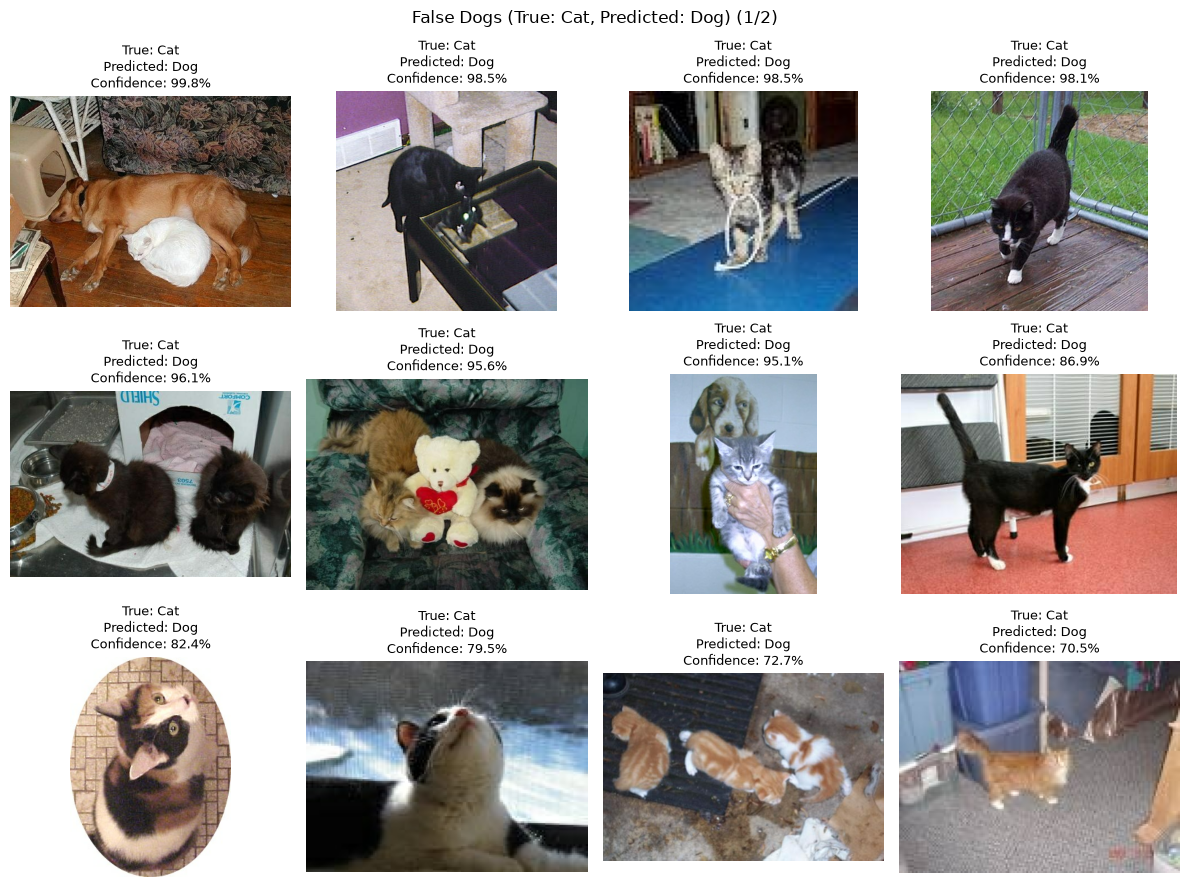

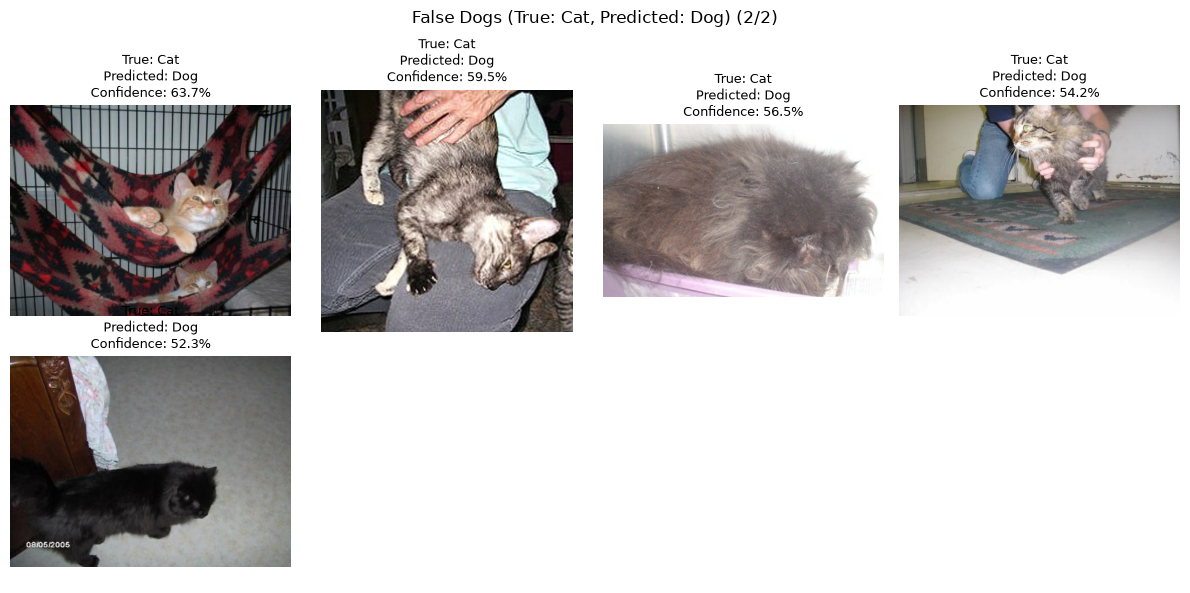

In [11]:
false_dogs = errors_df[errors_df["error_type"] == "false_dog"]
visualize_misclassified(false_dogs, "False Dogs (True: Cat, Predicted: Dog)")


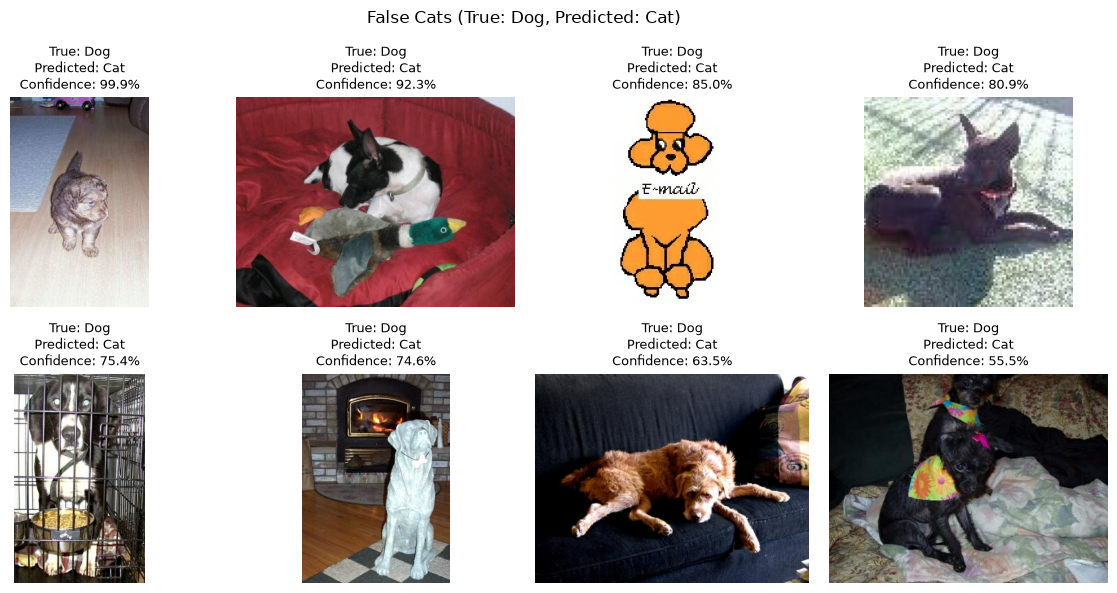

In [12]:
false_cats = errors_df[errors_df["error_type"] == "false_cat"]
visualize_misclassified(false_cats, "False Cats (True: Dog, Predicted: Cat)")


## 13. Most Confident Mistakes

**What are we doing?** Looking at the errors where the model was *most* confident, despite being
wrong -- these are more informative than a borderline 51% prediction, since something about the
image apparently looked strongly, misleadingly clear to the model.


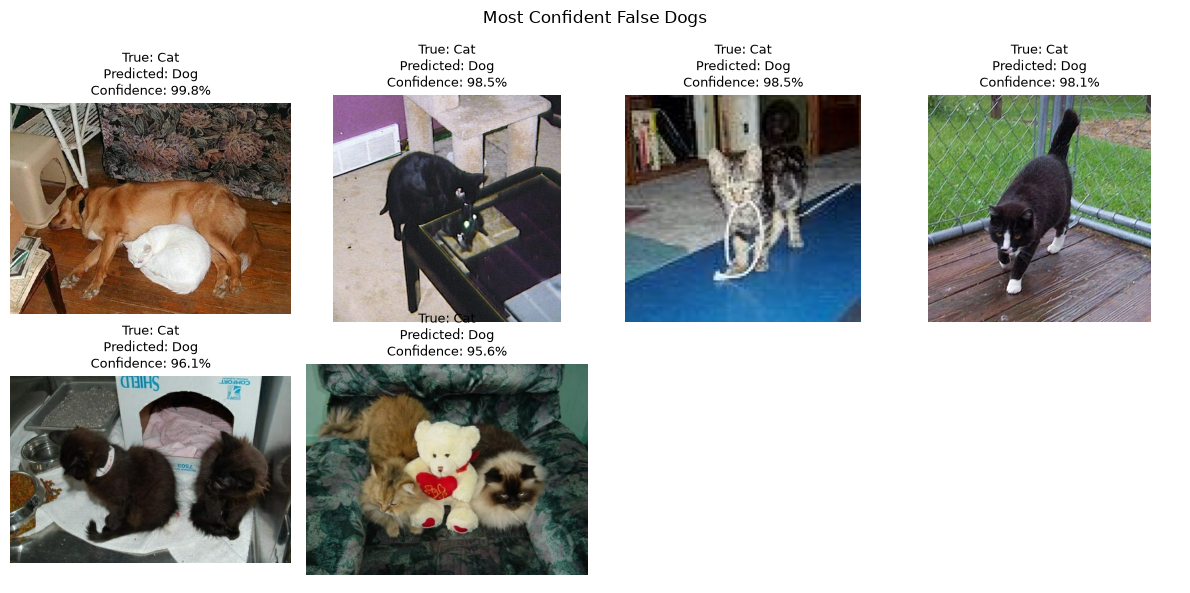

In [13]:
top_confident_false_dogs = false_dogs.sort_values("confidence", ascending=False).head(6)
visualize_misclassified(top_confident_false_dogs, "Most Confident False Dogs")


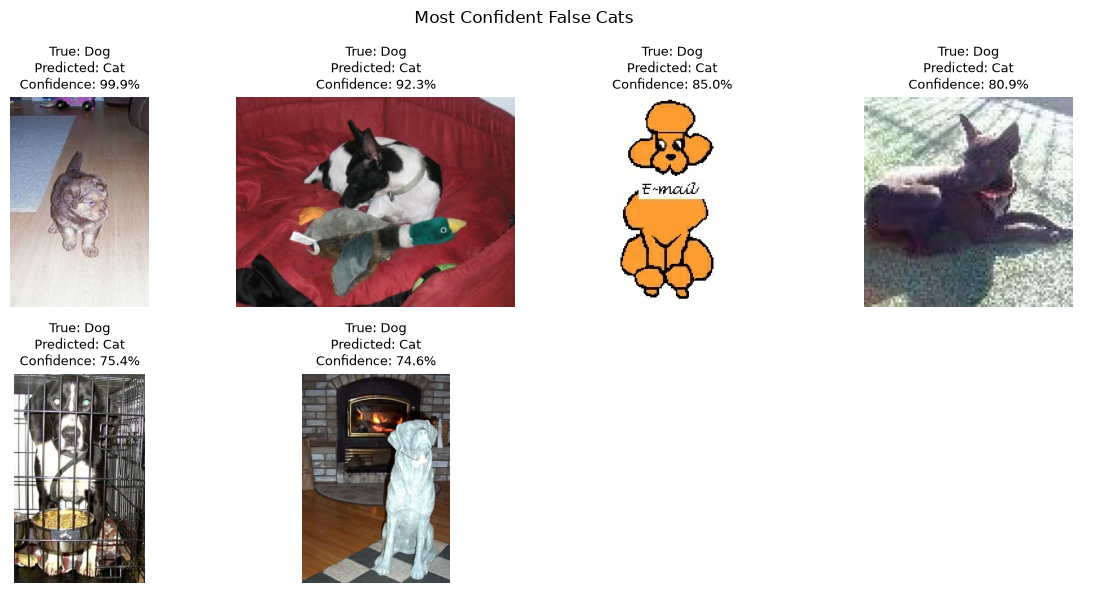

In [14]:
top_confident_false_cats = false_cats.sort_values("confidence", ascending=False).head(6)
visualize_misclassified(top_confident_false_cats, "Most Confident False Cats")


## 14. Most Uncertain Misclassified Examples

**What are we doing?** Finding the errors closest to the 0.5 decision threshold -- these are the
examples the model was least sure about, right before it happened to land on the wrong side.

We call these **the most uncertain misclassified examples according to the model's 0.5 decision
threshold** -- not "the hardest images" as an objective fact, since we don't have independent
evidence of difficulty beyond this model's own output.


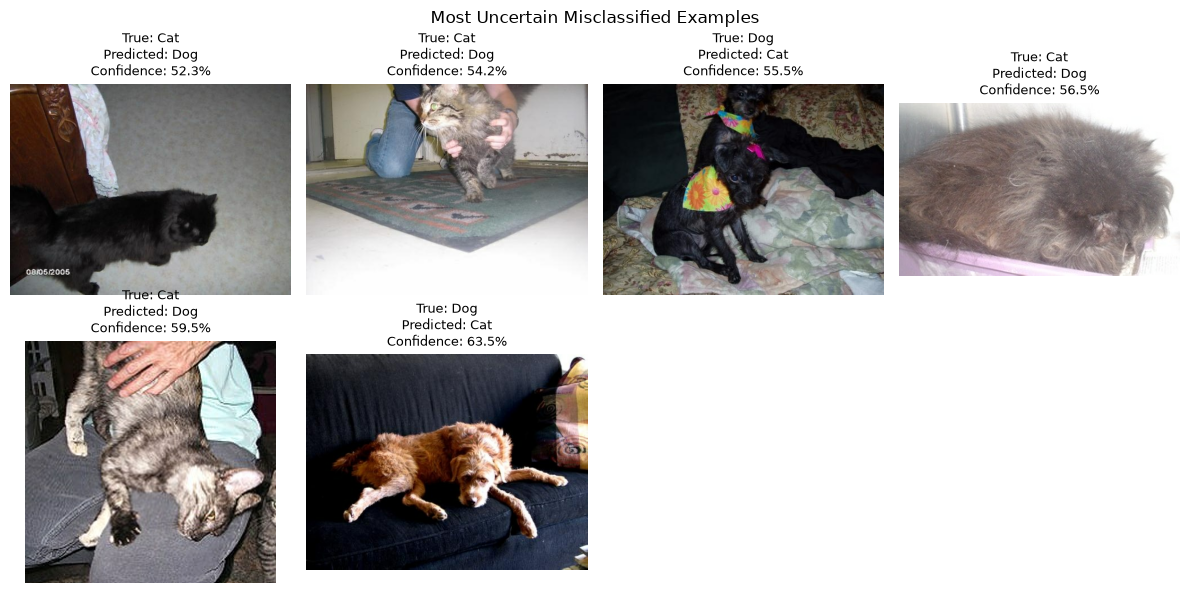

In [15]:
errors_df["distance_from_threshold"] = (errors_df["predicted_probability"] - 0.5).abs()
most_uncertain = errors_df.sort_values("distance_from_threshold", ascending=True).head(6)

visualize_misclassified(most_uncertain, "Most Uncertain Misclassified Examples")


## 15. Simple Image Statistics for the Errors

**What are we doing?** Checking a few basic properties (width, height, and aspect ratio) of
the 25 misclassified images. This gives us a simple description of their original image
dimensions and framing. We are not treating these statistics as evidence that the images are
unusual, because this notebook does not compare them against the full test set.


In [16]:
def get_image_dimensions(filepath):
    with Image.open(filepath) as img:
        width, height = img.size
    return pd.Series({"width": width, "height": height, "aspect_ratio": round(width / height, 3)})

error_dims = errors_df["filepath"].apply(get_image_dimensions)
errors_df = pd.concat([errors_df, error_dims], axis=1)

errors_df[["width", "height", "aspect_ratio"]].describe()


,width,height,aspect_ratio
count,25.000000,25.000000,25.000000
mean,347.080000,311.920000,1.127760
std,152.564992,119.622294,0.313998
min,90.000000,100.000000,0.556000
25%,220.000000,241.000000,0.982000
50%,354.000000,375.000000,1.305000
75%,500.000000,375.000000,1.333000
max,500.000000,500.000000,1.627000


## 16. Observed Error Patterns

Filled in after visually inspecting every one of the 25 misclassified images shown in Sections
12-13 (all 17 False Dogs and all 8 False Cats). Categories are not mutually exclusive -- a single
image can show more than one pattern, so the counts below do not sum to 25.

| Category                          | Example Observation | Number of Examples |
|------------------------------------|----------------------|--------------------:|
| Visual similarity between classes  | Tuxedo-patterned cats with coloring that overlaps common dog coat patterns; one small dog with markedly cat-like proportions (99.9% confidence) | 3 |
| Unusual pose                       | A dog curled up asleep next to a stuffed toy reading as cat-like (92.3%); a dog sprawled flat on a couch with an atypical silhouette (63.5%) | 3 |
| Occlusion                          | Subject partly hidden by cage bars, a wire cage, a patterned hammock/sling, or held in a person's hands | 5 |
| Image quality / blur               | Low light, blur, or a distant/small subject making detail hard to see | 6 |
| Cropping / framing                 | Tight or circular crop cutting off part of the animal | 1 |
| Multiple animals                   | A cat and a dog appear together in the same photo, or a cat/kitten appears with a dog figure or toy | 4 |
| Other                              | One False Cat (74.6%) is a stone/ceramic garden statue of a dog, not a live animal; another False Cat (85.0%) is a cartoon/clipart illustration of a poodle with an "E-mail" caption, not a photo at all | 2 |

**Note:** the 85.0%-confidence cartoon/clipart image is worth flagging beyond this table -- it
suggests at least one non-photographic image made it into the "Dog" class during data collection.
Worth a quick manual check of the source data if this project is revisited, though it is a single
image out of 24,966 and does not change the project's conclusions.

These counts come from a single visual pass and are meant as a rough map of *where* the errors
cluster, not a rigorous coded analysis -- worth a second look before quoting them anywhere formal.


## 17. False Dog vs. False Cat Balance

17 False Dogs vs. 8 False Cats (25 total). The model is more than twice as likely to mistake a cat
for a dog as the reverse in this error set. With only 25 errors total, this asymmetry is a
descriptive observation about this specific test run, not a statistically strong claim about a
systematic class bias.


## 18. Note on Final Metrics

Notebook 06 remains the authoritative source for Test Accuracy, Test Loss, Precision, Recall, F1,
ROC-AUC, and the confusion matrix. Nothing in this notebook recalculates or supersedes those
numbers -- the assertions in Section 7 exist specifically to confirm this notebook's predictions
are consistent with that established result, not to produce a second, competing evaluation.


# Final Findings

1. **How many test images were misclassified?** 25 out of 2,497 (1.00%).
2. **False Dogs:** 17 (Cat images predicted as Dog).
3. **False Cats:** 8 (Dog images predicted as Cat).
4. **Were the errors mostly low-confidence or high-confidence?** Confidence groups (Section 10):
   Low (<0.60) = 5, Medium (0.60-0.80) = 7, High (0.80-0.95) = 5, Very High (>=0.95) = 8. So 12 of
   the 25 errors (48%) sit in the Low/Medium bands, while 13 (52%) were made at 80%+ confidence,
   including 8 at 95%+. Unlike a purely borderline error profile, just over half of this model's
   mistakes were made with real confidence -- these are harder, more confidently-wrong cases
   rather than mostly uncertain guesses.
5. **What visual patterns were observed?** From Section 16's table: several examples show more
   than one animal in the same frame (a cat and a dog together, or a cat pictured with a dog
   figure or toy), which may give the model mixed visual cues. A noticeable group of errors also
   involve occlusion -- cats behind cage bars, wire mesh, a patterned hammock/sling, or held in a
   person's hands -- that could hide the features the model relies on. Among the False Cat errors,
   a few dogs appear in curled or sprawled poses that read visually closer to a resting cat than a
   standing dog, including one small dog with markedly cat-like proportions at 99.9% confidence.
   Two errors look like genuine edge cases outside the normal photo distribution -- one False Cat
   at 74.6% confidence is a stone garden statue of a dog rather than a live animal, and one False
   Cat at 85.0% confidence is a cartoon/clipart illustration of a poodle with a text caption, not a
   photograph at all. Several errors simply show low image quality (blur, low light, or a small
   subject relative to a cluttered background), which may leave the model with limited visual
   evidence either way. These are impressions from one visual pass, not a coded analysis, and are
   worth a second look before being treated as firm conclusions.
6. **Particularly difficult or highly confident mistakes?** Reference the specific examples shown
   in Sections 13-14 -- notably the 99.9%-confidence False Cat (a small, cat-proportioned dog) and
   the 99.8%-confidence False Dog (a cat photographed lying next to a real dog).
7. **What does this tell us beyond the accuracy number?** Accuracy alone doesn't show *which*
   direction the model's errors skew (17 vs. 8), whether mistakes are borderline or confidently
   wrong, or whether errors share any visible pattern -- all of which this notebook now shows.

**Avoid:** "The model fails because...", "This proves...", "The model is perfect." **Prefer:**
"Several examples appear to...", "The inspected examples suggest...".


## Project-Level Interpretation

```
Data Audit
    |
Controlled Data Pipeline
    |
Baseline CNN
    |
Controlled CNN Improvements
    |
Transfer Learning
    |
Fine-Tuning
    |
Final Unseen Test Evaluation
    |
Error Analysis
```

The project has now moved from **"how accurate is the model?"** (answered definitively in Notebook
06: 99.00%) to **"what kinds of examples does the model still struggle with?"** -- the question
this notebook exists to answer. No model, threshold, or result was changed to get here.
